In [ ]:
#!pip install albumentations
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import albumentations as A
import cv2
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
tf.config.list_physical_devices()

In [ ]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/parkinsons-drawing"

In [ ]:
os.listdir(base_path)

['.DS_Store',
 'wave',
 'drawings',
 'spiral',
 'spiral_augmented_combined',
 'wave_augmented_combined']

In [ ]:
for root, dirs, files in os.walk(base_path):
  level = root.replace(base_path, '').count(os.sep)
  indent = ' '* 4 * level
  print(f"{indent}{os.path.basename(root)}/")

  sub_indent = ' ' * 4 * (level + 1)

  for f in files:
    if not f.lower().endswith('.png'):
      print(f"{sub_indent}{f}")

parkinsons-drawing/
    .DS_Store
    wave/
        .DS_Store
        training/
            parkinson/
            healthy/
        testing/
            .DS_Store
            healthy/
            parkinson/
    drawings/
        spiral/
            testing/
                parkinson/
                healthy/
            training/
                parkinson/
                healthy/
        wave/
            testing/
                healthy/
                parkinson/
            training/
                healthy/
                parkinson/
    spiral/
        .DS_Store
        training/
            .DS_Store
            healthy/
            parkinson/
        testing/
            .DS_Store
            healthy/
            parkinson/
    spiral_augmented_combined/
        training/
            healthy/
            parkinson/
        testing/
            healthy/
            parkinson/
    wave_augmented_combined/
        training/
            healthy/
            parkinson/


# Wave

In [ ]:
wave_train = "/content/drive/MyDrive/parkinsons-drawing/wave/training"
wave_test = "/content/drive/MyDrive/parkinsons-drawing/wave/testing"
def count_images_per_class(folder_path):
    counts = {}
    classes = os.listdir(folder_path)
    for cls in classes:
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

print("Wave Train:")
wave_train_counts = count_images_per_class(wave_train)
print(wave_train_counts)
print("Wave Test:")
wave_test_counts = count_images_per_class(wave_test)
print(wave_test_counts)

Wave Train:
{'parkinson': 36, 'healthy': 36}
Wave Test:
{'healthy': 15, 'parkinson': 15}


In [ ]:
#Augmentation
wave_path = "/content/drive/MyDrive/parkinsons-drawing/wave"
#path ที่ใช้เก็บรูปหลังจากทำ augmentation
waveAugmented_path = "/content/drive/MyDrive/parkinsons-drawing/wave_augmented_combined"

ITERATIONS = 20 #สร้าง 20รูปใหม่/1รูป

transform = A.Compose([

    # A.ElasticTransform(p=0.8, alpha=80, sigma=80 * 0.05, alpha_affine=80 * 0.03),

    A.Rotate(limit=15, p=0.7),

    A.HorizontalFlip(p=0.5),

    A.RandomBrightnessContrast(p=0.4, brightness_limit=0.1, contrast_limit=0.1)
])


def create_augmented_files(src_dir, dest_dir, iterations):
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    print(f"Processing folder: {src_dir}")

    for filename in os.listdir(src_dir):
        if filename.endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(src_dir, filename)
            base_name = os.path.splitext(filename)[0]

            img = cv2.imread(img_path)

            if img is None:
                print(f"Warning: Could not read image {img_path}. Skipping.")
                continue

            cv2.imwrite(os.path.join(dest_dir, filename), img)

            for i in range(iterations):

                transformed = transform(image=img)
                augmented_image = transformed["image"]

                new_filename = f"{base_name}_aug_combined_{i}.png"
                full_output_path = os.path.join(dest_dir, new_filename)

                cv2.imwrite(full_output_path, augmented_image)

for subset in ["training"]:
    for label in ["healthy", "parkinson"]:
        src_dir = os.path.join(wave_path, subset, label)
        dest_dir = os.path.join(waveAugmented_path, subset, label)

        if not os.path.exists(src_dir):
            print(f"Warning: Source directory not found: {src_dir}. Skipping.")
            continue

        create_augmented_files(src_dir, dest_dir, ITERATIONS)

print({waveAugmented_path})

Processing folder: /content/drive/MyDrive/parkinsons-drawing/wave/training/healthy
Processing folder: /content/drive/MyDrive/parkinsons-drawing/wave/training/parkinson
{'/content/drive/MyDrive/parkinsons-drawing/wave_augmented_combined'}


In [ ]:
waveAugmented_path = "/content/drive/MyDrive/parkinsons-drawing/wave_augmented_combined"
train_dir_w = os.path.join(waveAugmented_path, "training")
test_dir_w = os.path.join("/content/drive/MyDrive/parkinsons-drawing/wave", "testing")

# กำหนดขนาดรูปภาพและขนาดของ Batch (จำนวนรูปที่จะโหลดในแต่ละครั้ง)
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_dataset_w = tf.keras.utils.image_dataset_from_directory(
    train_dir_w,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',        # ให้ label เป็นตัวเลข (0, 1, 2...)
    validation_split=0.2,    # แบ่ง 20% ของข้อมูลนี้ไว้เป็น Validation set
    subset='training',       # ระบุว่าก้อนนี้คือข้อมูล "training"
    seed=123  ,               # ใส่ seed เพื่อให้การสุ่มแบ่งข้อมูลเหมือนเดิมทุกครั้ง
    color_mode='grayscale'
)

# โหลดข้อมูลสำหรับ Validation (จาก 20% ที่แบ่งไว้)
validation_dataset_w = tf.keras.utils.image_dataset_from_directory(
    train_dir_w,               # ใช้ path เดียวกับข้างบน
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    validation_split=0.2,
    subset='validation',     # ระบุว่าก้อนนี้คือข้อมูล "validation"
    seed=123 , # ใช้ seed เดียวกันเพื่อให้ข้อมูลไม่ปนกัน
    color_mode='grayscale'
)

# โหลดข้อมูลสำหรับ Testing (จากโฟลเดอร์ testing)
test_dataset_w = tf.keras.utils.image_dataset_from_directory(
    test_dir_w,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    color_mode='grayscale',  # โหลดเป็น Grayscale
    shuffle=False  # ปกติเราจะไม่สลับลำดับข้อมูล Test
)

# --- 3. ตรวจสอบผลลัพธ์ ---

# เราสามารถดูได้เลยว่ามันเจอ Class (Label) อะไรบ้าง
class_names = train_dataset_w.class_names
print(f"โปรแกรมเจอ Labels (Classes) คือ: {class_names}")

# Keras จะเรียงลำดับ Label ตามตัวอักษร
# ดังนั้น 'healthy' จะถูกกำหนดให้เป็น Label 0
# และ 'parkinson' จะถูกกำหนดให้เป็น Label 1

print(f"'{class_names[0]}' ถูกกำหนดเป็น Label 0")
print(f"'{class_names[1]}' ถูกกำหนดเป็น Label 1")

Found 1512 files belonging to 2 classes.
Using 1210 files for training.
Found 1512 files belonging to 2 classes.
Using 302 files for validation.
Found 30 files belonging to 2 classes.
โปรแกรมเจอ Labels (Classes) คือ: ['healthy', 'parkinson']
'healthy' ถูกกำหนดเป็น Label 0
'parkinson' ถูกกำหนดเป็น Label 1


Class: ['healthy', 'parkinson']


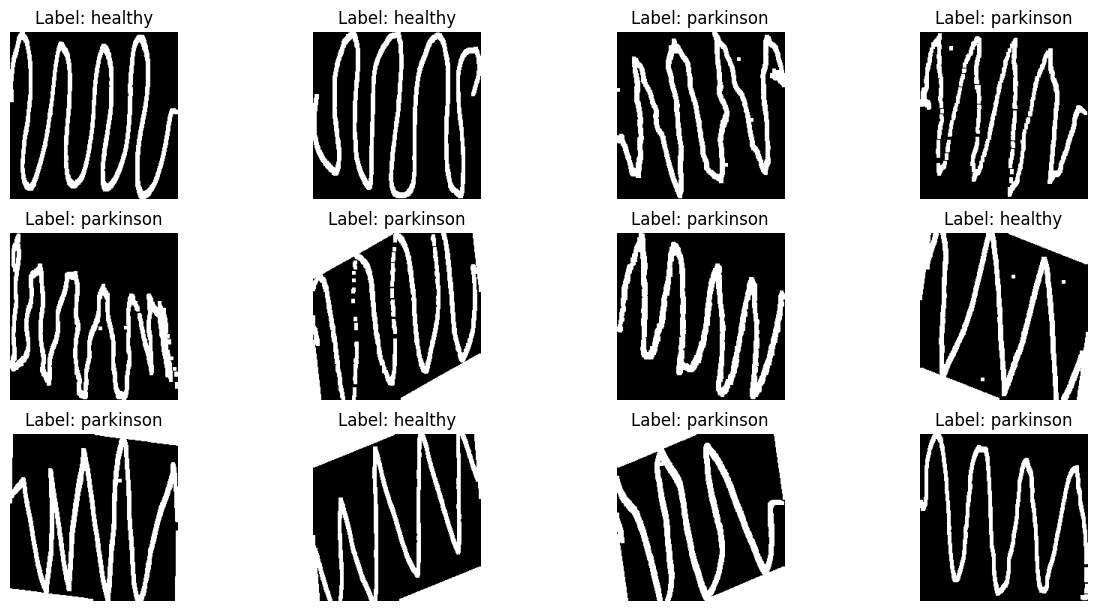

In [ ]:
class_names = train_dataset_w.class_names
print(f"Class: {class_names}")

def preprocess_image(image, label, normalize=True):

    image_float = tf.cast(image, tf.float32)
    processed_image = tf.where(image_float < 190.0, 255.0, 0.0)

    kernel = tf.ones((5, 5, 1), dtype=tf.float32)
    dilated_image = tf.nn.dilation2d(
        input=processed_image,
        filters=kernel,
        strides=(1, 1, 1, 1),
        padding="SAME",
        dilations=(1, 1, 1, 1),
        data_format="NHWC"
    )

    if normalize:
        final_image = dilated_image / 255.0
    else:
        final_image = dilated_image

    return final_image, label

AUTOTUNE = tf.data.AUTOTUNE

train_dataset_w = train_dataset_w.map(lambda x, y: preprocess_image(x, y, normalize=True),
                                      num_parallel_calls=AUTOTUNE)
validation_dataset_w = validation_dataset_w.map(lambda x, y: preprocess_image(x, y, normalize=True),
                                                num_parallel_calls=AUTOTUNE)
test_dataset_w = test_dataset_w.map(lambda x, y: preprocess_image(x, y, normalize=True),
                                    num_parallel_calls=AUTOTUNE)

train_dataset_w = train_dataset_w.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset_w = validation_dataset_w.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset_w = test_dataset_w.prefetch(buffer_size=AUTOTUNE)

plt.figure(figsize=(15, 10))
for images, labels in train_dataset_w.take(1):
    for i in range(12):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(f"Label: {class_names[labels[i]]}")
        plt.axis("off")
plt.show()


In [ ]:
def convert_to_rgb(dataset):
    def to_rgb(image, label):
        return tf.image.grayscale_to_rgb(image), label
    return dataset.map(to_rgb, num_parallel_calls=tf.data.AUTOTUNE)

wave_train_dataset_rgb = convert_to_rgb(train_dataset_w)
wave_validation_dataset_rgb = convert_to_rgb(validation_dataset_w)
wave_test_dataset_rgb = convert_to_rgb(test_dataset_w)


In [ ]:
for img, lbl in wave_train_dataset_rgb.take(1):
    print(img.shape)

(16, 224, 224, 3)


In [ ]:
def plot_history(history):
    """
    Plots the training and validation accuracy and loss from the training history.

    Args:
    - history: A History object. The history object is returned by the `fit` method of a Keras model.
    """
    # Plot accuracy history
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    # Plot loss history
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
output_layer = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output_layer)

for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(wave_train_dataset_rgb, validation_data=wave_validation_dataset_rgb, epochs=20)

print("\n Test Set")
test_loss, test_acc = model.evaluate(wave_test_dataset_rgb)
print(f'\nTest Accuracy: {test_acc * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5893 - loss: 0.6857 - val_accuracy: 0.8311 - val_loss: 0.4495
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 66s 867ms/step - accuracy: 0.8295 - loss: 0.4250 - val_accuracy: 0.8609 - val_loss: 0.3628
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 84s 888ms/step - accuracy: 0.8648 - loss: 0.3485 - val_accuracy: 0.8808 - val_loss: 0.3179
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 908ms/step - accuracy: 0.8745 - loss: 0.3059 - val_accuracy: 0.8874 - val_loss: 0.2882
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 82s 916ms/step - accuracy: 0.9002 - loss: 0.2766 - val_accuracy: 0.8974 - val_loss: 0.2664
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 936ms/step - accuracy: 0.9068 - loss: 0.2543 - val_accuracy: 0.9040 - val_loss: 0.2494
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 73s 815ms/step - accuracy: 0.9159 - loss: 0.2363 - val_accuracy: 0.9106 - val_loss: 0.2356
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 91s 935ms/step - accuracy: 0.9238 - loss: 0.2212 - val_accura

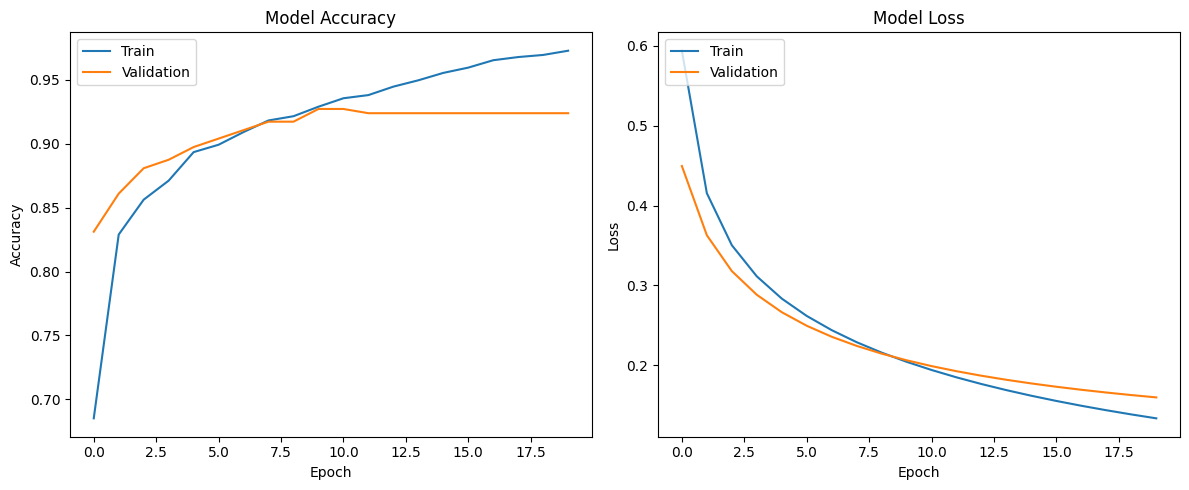

In [ ]:
plot_history(history)

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce feature maps to a single vector per channel
output_layer = Dense(1, activation='sigmoid')(x)  # Final layer for classification

# Create the final model
model = Model(inputs=base_model.input, outputs=output_layer)

# Freeze or unfreeze layer ใน base โมเดล
for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(wave_train_dataset_rgb, validation_data=wave_validation_dataset_rgb, epochs=30)

print("\n--- กำลังประเมินผลด้วย Test Set ---")
test_loss, test_acc = model.evaluate(wave_test_dataset_rgb)
print(f'\nTest Accuracy: {test_acc * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 79s 960ms/step - accuracy: 0.6850 - loss: 0.5933 - val_accuracy: 0.8311 - val_loss: 0.4232
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 62s 816ms/step - accuracy: 0.8478 - loss: 0.4042 - val_accuracy: 0.8576 - val_loss: 0.3524
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 64s 847ms/step - accuracy: 0.8656 - loss: 0.3377 - val_accuracy: 0.8742 - val_loss: 0.3121
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 945ms/step - accuracy: 0.8828 - loss: 0.2981 - val_accuracy: 0.8841 - val_loss: 0.2843
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 81s 936ms/step - accuracy: 0.9081 - loss: 0.2702 - val_accuracy: 0.8940 - val_loss: 0.2635
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 70s 927ms/step - accuracy: 0.9149 - loss: 0.2489 - val_accuracy: 0.8940 - val_loss: 0.2471
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 945ms/step - accuracy: 0.9225 - loss: 0.2316 - val_accuracy: 0.9040 - val_loss: 0.2338
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 62s 814ms/step - accuracy: 0.9310 - loss: 0.2171 - val_accu

In [ ]:
plot_history(history)

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce feature maps to a single vector per channel
output_layer = Dense(1, activation='sigmoid')(x)  # Final layer for classification

# Create the final model
model = Model(inputs=base_model.input, outputs=output_layer)

# Freeze or unfreeze layer ใน base โมเดล
for layer in base_model.layers[-5:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(wave_train_dataset_rgb, validation_data=wave_validation_dataset_rgb, epochs=30)

print("\n--- กำลังประเมินผลด้วย Test Set ---")
test_loss, test_acc = model.evaluate(wave_test_dataset_rgb)
print(f'\nTest Accuracy: {test_acc * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

In [ ]:
plot_history(history)